In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import folium  # 交互式地图
from folium.plugins import HeatMap

# 加载合并后的总数据
df = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")
df["date"] = pd.to_datetime(df["date"])


关键变量缺失值：
 秸秆火点数量                      0
wind_speed                  0
2m_relative_humidity     5456
逆温强度(℃/100m)            69105
pm25_concentration          0
dtype: int64

清洗后数据量：57526行（原数据：129964行）


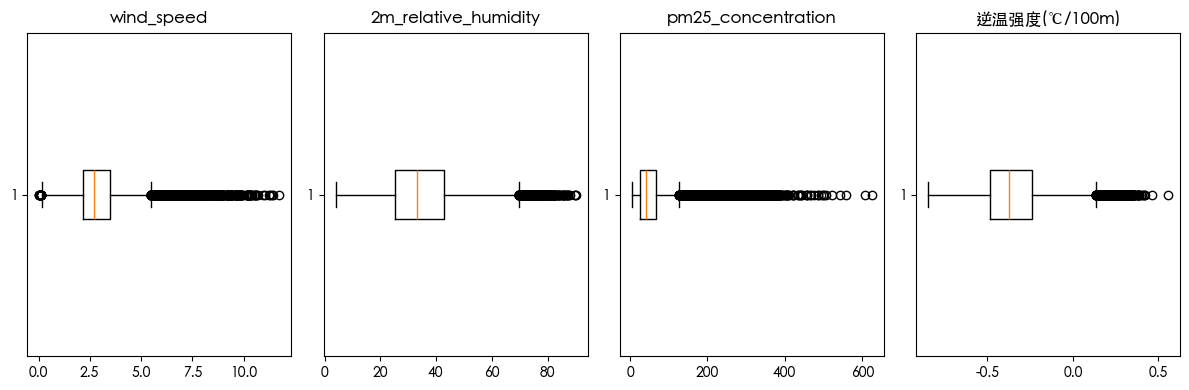

In [30]:
plt.rcParams["font.family"] = ["Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

# （1）缺失值检查
key_cols = ["秸秆火点数量", "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)", "pm25_concentration"]
missing = df[key_cols].isnull().sum()
print("\n关键变量缺失值：\n", missing)

# 处理缺失值
df_clean = df.dropna(subset=key_cols).copy()
print(f"\n清洗后数据量：{df_clean.shape[0]}行（原数据：{df.shape[0]}行）")

# （2）异常值检查（箱线图）
plt.figure(figsize=(12, 4))
for i, col in enumerate(["wind_speed", "2m_relative_humidity", "pm25_concentration", "逆温强度(℃/100m)"]):
    plt.subplot(1, 4, i+1)
    plt.boxplot(df_clean[col], vert=False)
    plt.title(col)  # 此时中文标题可正常显示
plt.tight_layout()
plt.show()

# 处理异常值
for col in ["pm25_concentration"]:
    upper = df_clean[col].quantile(0.99)
    df_clean.loc[df_clean[col] > upper, col] = upper

In [31]:
# 计算关键变量的均值、中位数、范围等
stats = df_clean[["秸秆火点数量", "平均火点强度", "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)", "pm25_concentration"]].describe()
print("\n核心变量统计特征：\n", stats)


核心变量统计特征：
              秸秆火点数量        平均火点强度    wind_speed  2m_relative_humidity  \
count  57526.000000  57526.000000  57526.000000          57526.000000   
mean       0.231235     14.611734      2.922052             34.836592   
std        0.738582     16.660041      1.253812             12.800320   
min        0.000000      0.000000      0.036474              3.998568   
25%        0.000000      6.300000      2.143487             25.161025   
50%        0.000000      9.500000      2.711610             33.102266   
75%        0.000000     16.200000      3.481704             42.933501   
max       15.000000    433.600000     11.742203             89.989080   

       逆温强度(℃/100m)  pm25_concentration  
count  57526.000000        57526.000000  
mean      -0.353716           55.335930  
std        0.184735           46.129292  
min       -0.846602            5.062128  
25%       -0.487111           25.926447  
50%       -0.373364           40.136473  
75%       -0.238278           66.590

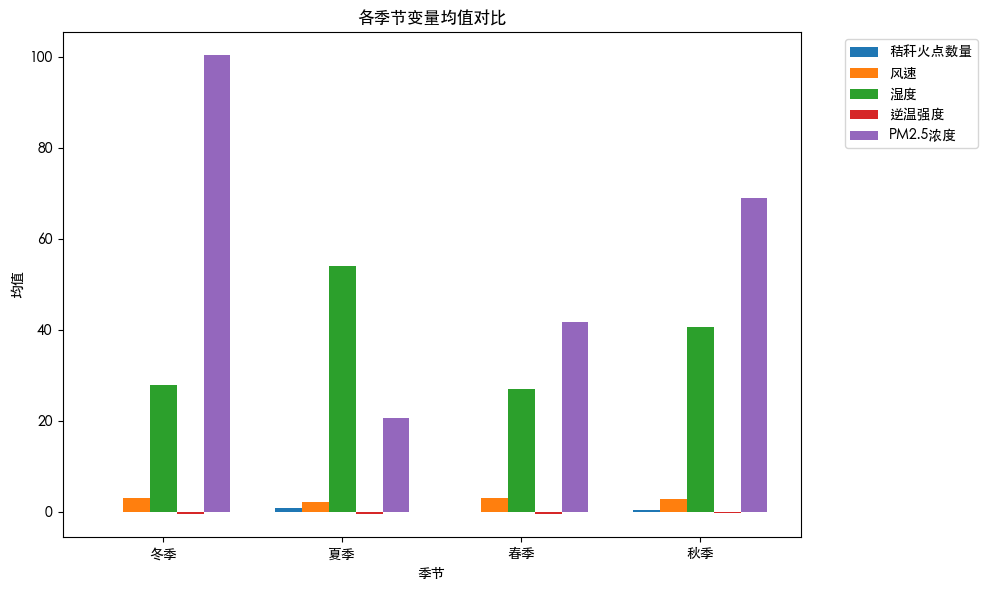

In [32]:
# 提取季节（按月份划分）
df_clean["season"] = df_clean["date"].dt.month.map({
    12: "冬季", 1: "冬季", 2: "冬季",
    3: "春季", 4: "春季", 5: "春季",
    6: "夏季", 7: "夏季", 8: "夏季",
    9: "秋季", 10: "秋季", 11: "秋季"
})

# 按季节计算均值
seasonal_data = df_clean.groupby("season")[
    ["秸秆火点数量", "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)", "pm25_concentration"]
].mean().reset_index()

# 可视化季节趋势（柱状图）
plt.figure(figsize=(10, 6))
x = np.arange(len(seasonal_data))
width = 0.15

plt.bar(x - 2*width, seasonal_data["秸秆火点数量"], width, label="秸秆火点数量")
plt.bar(x - width, seasonal_data["wind_speed"], width, label="风速")
plt.bar(x, seasonal_data["2m_relative_humidity"], width, label="湿度")
plt.bar(x + width, seasonal_data["逆温强度(℃/100m)"], width, label="逆温强度")
plt.bar(x + 2*width, seasonal_data["pm25_concentration"], width, label="PM2.5浓度")

plt.xticks(x, seasonal_data["season"])
plt.xlabel("季节")
plt.ylabel("均值")
plt.title("各季节变量均值对比")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

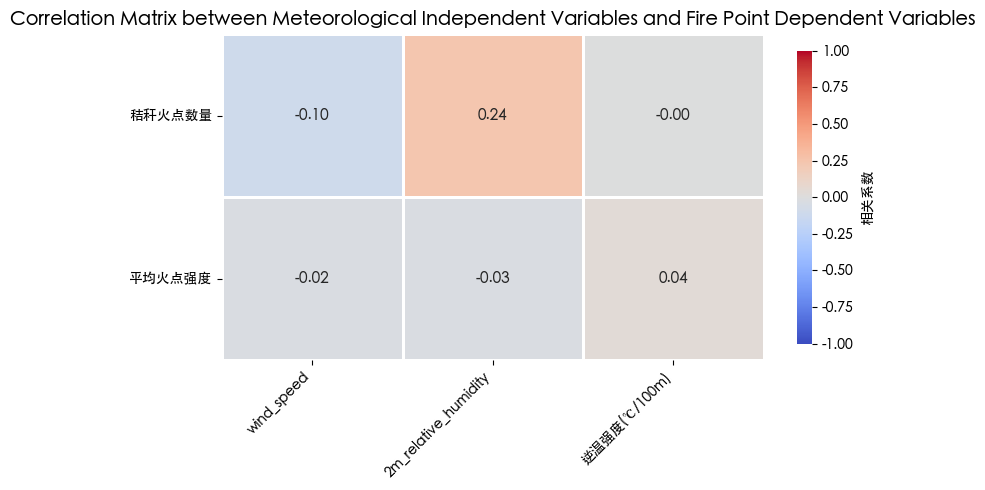

In [33]:
import seaborn as sns

# ---------------------- 变量定义 ----------------------
# 自变量（气象数据）
independent_vars = ["wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)"]
# 因变量（火点特征）
dependent_vars = ["秸秆火点数量", "平均火点强度"]

# 提取需要的变量列
corr_data = df_clean[independent_vars + dependent_vars]

# 计算全量相关系数矩阵，再筛选出“因变量×自变量”的子集
corr = corr_data.corr()
corr_subset = corr.loc[dependent_vars, independent_vars]

# ---------------------- 绘制热力图 ----------------------
plt.figure(figsize=(8, 5))  
sns.heatmap(
    corr_subset, 
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    cbar_kws={"label": "相关系数", "shrink": 0.9},
    linewidths=0.8,
    # X轴显示自变量，Y轴显示因变量
    xticklabels=independent_vars,
    yticklabels=dependent_vars
)

# 标题和标签调整
plt.title("Correlation Matrix between Meteorological Independent Variables and Fire Point Dependent Variables", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)  # 自变量标签
plt.yticks(rotation=0, fontsize=10)  # 因变量标签
plt.tight_layout()
plt.show()

In [29]:
!pip install statsmodels

In [34]:
import statsmodels.api as sm

# 1. 确保 X 和 y 基于同一批清洗后的数据
X = df_clean[["秸秆火点数量", "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)"]].copy()

# 2. 生成交互项
X["火点×风速"] = X["秸秆火点数量"] * X["wind_speed"]
X["火点×湿度"] = X["秸秆火点数量"] * X["2m_relative_humidity"]
X["火点×逆温"] = X["秸秆火点数量"] * X["逆温强度(℃/100m)"]

# 3. 再次检查 X 中是否存在 NaN 或 inf
print("X 中的缺失值：\n", X.isnull().sum())
print("X 中的无穷大值：\n", (X == np.inf).sum())  # 需要 import numpy as np

# 4. 若存在异常值，进一步清洗（例如删除或填充）
X = X.replace([np.inf, -np.inf], np.nan)  # 将 inf 转为 NaN
X = X.dropna()  # 删除含 NaN 的行

# 5. 确保 y 与清洗后的 X 行数一致
valid_indices = X.index
y = df_clean.loc[valid_indices, "pm25_concentration"]

# 6. 添加常数项并拟合模型
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print("\n回归模型结果：\n", model.summary())

X 中的缺失值：
 秸秆火点数量                  0
wind_speed              0
2m_relative_humidity    0
逆温强度(℃/100m)            0
火点×风速                   0
火点×湿度                   0
火点×逆温                   0
dtype: int64
X 中的无穷大值：
 秸秆火点数量                  0
wind_speed              0
2m_relative_humidity    0
逆温强度(℃/100m)            0
火点×风速                   0
火点×湿度                   0
火点×逆温                   0
dtype: int64

回归模型结果：
                             OLS Regression Results                            
Dep. Variable:     pm25_concentration   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     1921.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:00:34   Log-Likelihood:            -2.9599e+05
No. Observations:               57526   AIC:                         5.920e+05
Df Residuals:             

In [35]:
import geopandas as gpd
from shapely.geometry import Point

# 将火点经纬度转换为地理点（WGS84坐标系）
geometry = [Point(xy) for xy in zip(df_clean["fire_longitude"], df_clean["fire_latitude"])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs="EPSG:4326")

属性表字段名： ['地名', '区划码', '县级', '县级码', '县级类', '地级', '地级码', '地级类', '省级', '省级码', '省级类', '曾用名', '备注', 'ENG_NAME', 'VAR_NAME', 'code', 'NAME_3', 'VAR_NAME3', 'GID_3', 'TYPE_3', 'NAME_2', 'VAR_NAME2', 'GID_2', 'TYPE_2', 'NAME_1', 'VAR_NAME1', 'GID_1', 'TYPE_1', 'year', 'geometry']
黑龙江省边界数据： (1, 30)


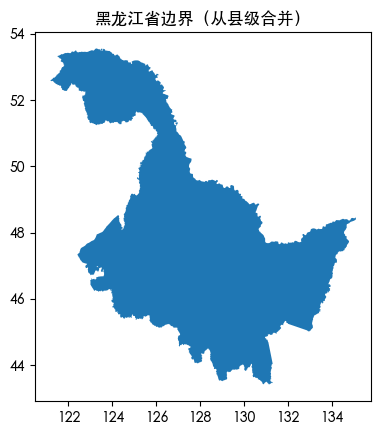

In [36]:
# 1. 加载中国县级边界SHP文件
china_counties = gpd.read_file("CHN_County.shp")

# 2. 查看属性表，确定“省份名称”对应的字段名
print("属性表字段名：", china_counties.columns.tolist())

# 3. 筛选出黑龙江省的所有县
heilongjiang_counties = china_counties[china_counties["省级"] == "黑龙江省"]

# 4. 将县级边界合并为黑龙江省省级边界
heilongjiang = heilongjiang_counties.dissolve()  # 合并多个多边形为一个

# 5. 查看结果
print("黑龙江省边界数据：", heilongjiang.shape)
heilongjiang.plot()
plt.title("黑龙江省边界（从县级合并）")
plt.show()

In [37]:
from shapely.geometry import Point

# 1. 加载火点数据并转换为地理格式
df = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")
geometry = [Point(xy) for xy in zip(df["fire_longitude"], df["fire_latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# 2. 确保坐标系一致（若SHP文件坐标系不同，需转换）
if gdf.crs != heilongjiang.crs:
    heilongjiang = heilongjiang.to_crs(gdf.crs)  # 转换为与火点数据相同的坐标系

# 3. 裁剪：只保留黑龙江省内的火点
gdf_hlj = gpd.clip(gdf, heilongjiang)  # 仅保留落在黑龙江省内的点

print(f"裁剪前火点数量：{len(gdf)}，裁剪后：{len(gdf_hlj)}")

裁剪前火点数量：129964，裁剪后：89009


In [38]:
import geopandas as gpd
from shapely.geometry import Point

# 假设经纬度列名为 "fire_latitude" 和 "fire_longitude"
geometry = [Point(xy) for xy in zip(df_clean["fire_longitude"], df_clean["fire_latitude"])]

# 转换为GeoDataFrame，指定坐标系为WGS84（EPSG:4326）
gdf_hlj = gpd.GeoDataFrame(df_clean, geometry=geometry, crs="EPSG:4326")

print(gdf_hlj.head())

        date  fire_latitude  fire_longitude  秸秆火点数量  平均火点强度  meteo_latitude  \
2 2010-04-16           45.5           122.9       0     8.5            45.5   
5 2010-04-16           45.8           128.8       0     5.4            45.8   
6 2010-04-16           45.8           130.6       0     3.7            45.8   
7 2010-04-16           45.8           130.9       0     6.8            45.8   
9 2010-04-16           46.0           122.9       0    13.1            46.0   

   meteo_longitude  匹配距离(°)  t2m_celsius  wind_speed  2m_relative_humidity  \
2            122.9      0.0     1.191803    2.740311             21.223955   
5            128.9      0.1    -3.448090    1.677750             32.696950   
6            130.6      0.0     0.490631    1.060484             30.583456   
7            130.9      0.0     0.221832    1.291094             33.843700   
9            122.9      0.0     0.128326    2.804263             20.909660   

       t850  pm25_latitude  pm25_longitude  pm25_concent

PM2.5图例最大值设置为：155.9μg/m³


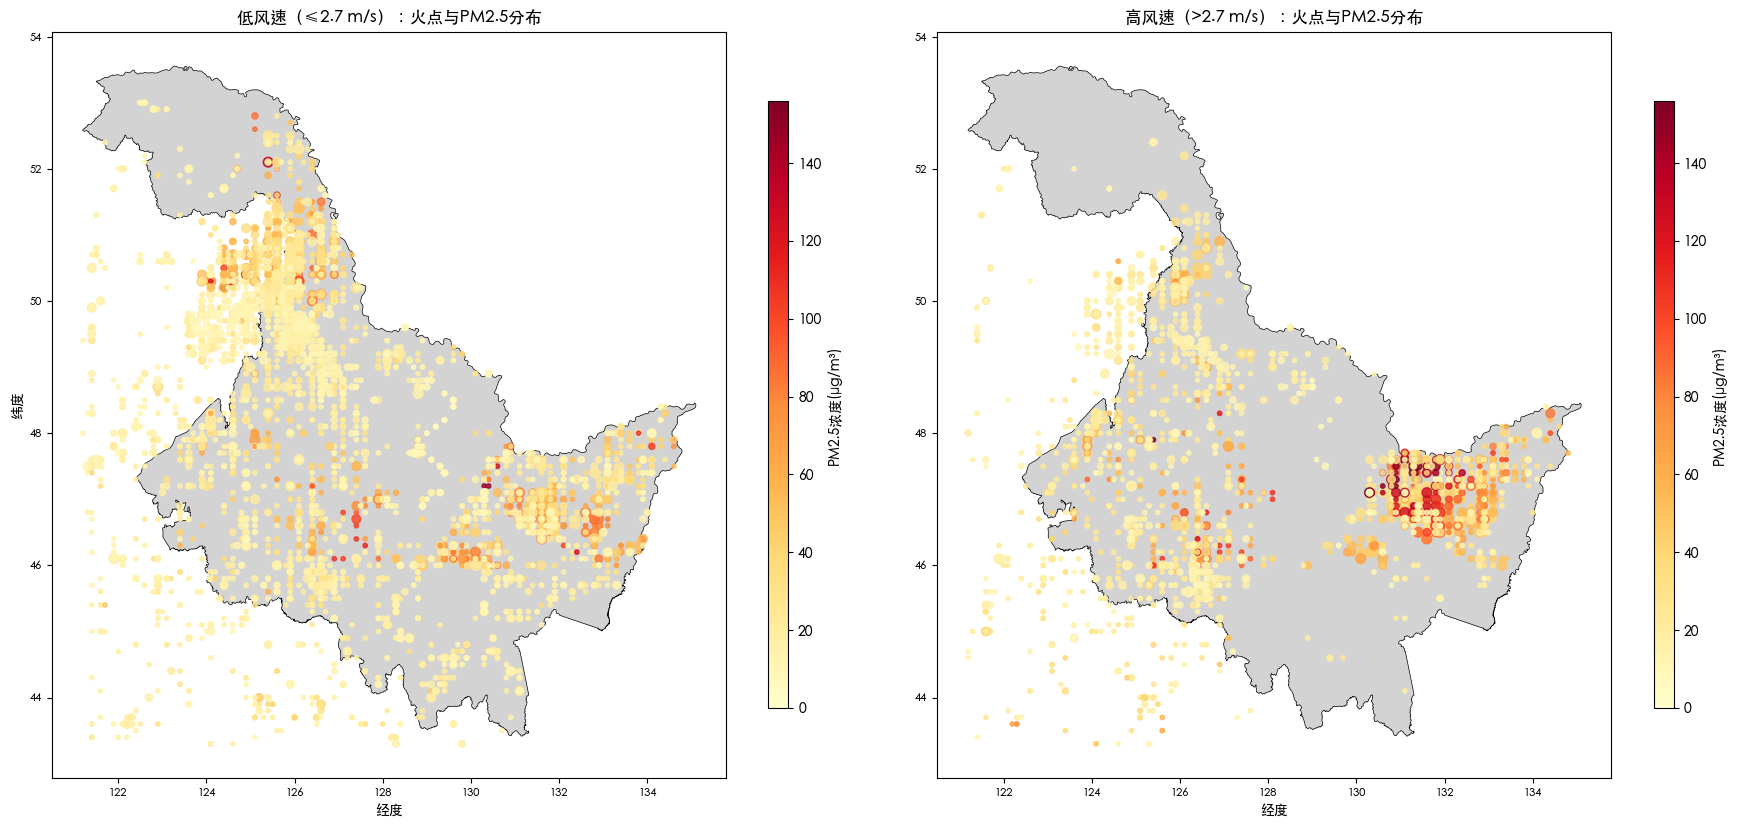

In [39]:
# 1. 按风速分组（同之前步骤）
wind_median = gdf_hlj["wind_speed"].median()
gdf_low_wind = gdf_hlj[gdf_hlj["wind_speed"] <= wind_median]
gdf_high_wind = gdf_hlj[gdf_hlj["wind_speed"] > wind_median]

# ---------------------- 计算并设置PM2.5的最大值 ----------------------
pm25_max = gdf_hlj["pm25_concentration"].quantile(0.95)  # 取95%分位数
print(f"PM2.5图例最大值设置为：{pm25_max:.1f}μg/m³")

# 2. 绘制对比地图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ---------------------- 左图：低风速 ----------------------
heilongjiang.plot(ax=ax1, color="lightgray", edgecolor="black", linewidth=0.5)
scatter_low = gdf_low_wind.plot(
    ax=ax1,
    column="pm25_concentration",
    cmap="YlOrRd",
    s=gdf_low_wind["秸秆火点数量"].clip(upper=5) * 10,
    alpha=0.8,
    legend=True,
    # 限制颜色映射范围（核心参数）
    vmin=0,  # 最小值从0开始（可选）
    vmax=pm25_max,  # 最大值设为计算的分位数或手动值
    legend_kwds={
        "label": "PM2.5浓度(μg/m³)",
        "orientation": "vertical",
        "shrink": 0.8,
        "pad": 0.05,
        "aspect": 30
    }
)
ax1.set_title(f"低风速（≤{wind_median:.1f} m/s）：火点与PM2.5分布", fontsize=12)
ax1.set_xlabel("经度", fontsize=10)
ax1.set_ylabel("纬度", fontsize=10)
ax1.tick_params(axis="both", labelsize=8)

# ---------------------- 右图：高风速 ----------------------
heilongjiang.plot(ax=ax2, color="lightgray", edgecolor="black", linewidth=0.5)
scatter_high = gdf_high_wind.plot(
    ax=ax2,
    column="pm25_concentration",
    cmap="YlOrRd",
    s=gdf_high_wind["秸秆火点数量"].clip(upper=5) * 10,
    alpha=0.8,
    legend=True,
    # 保持与左图一致的范围，确保对比性
    vmin=0,
    vmax=pm25_max,
    legend_kwds={
        "label": "PM2.5浓度(μg/m³)",
        "orientation": "vertical",
        "shrink": 0.8,
        "pad": 0.05,
        "aspect": 30
    }
)
ax2.set_title(f"高风速（>{wind_median:.1f} m/s）：火点与PM2.5分布", fontsize=12)
ax2.set_xlabel("经度", fontsize=10)
ax2.set_ylabel("")
ax2.tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
plt.show()

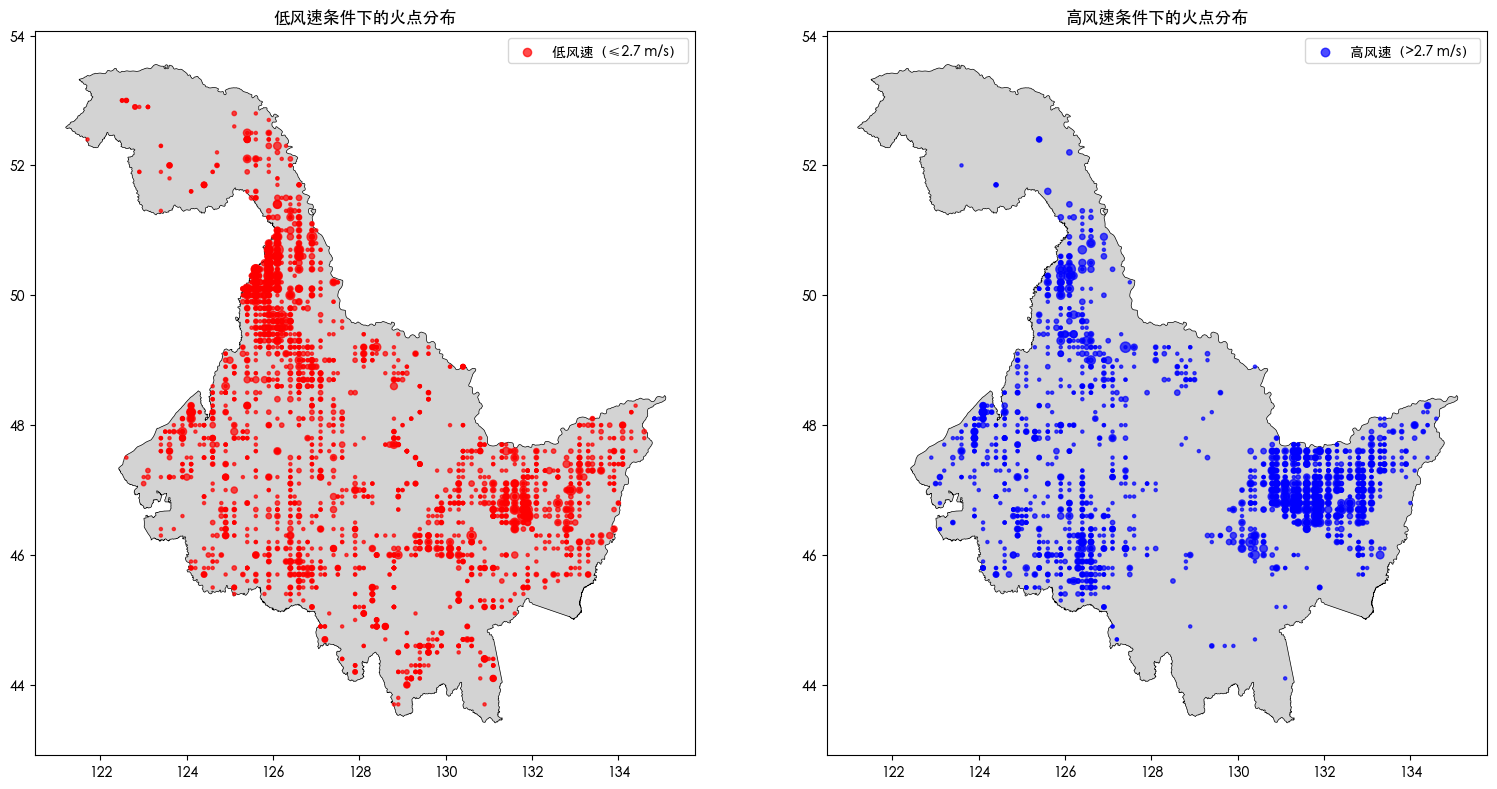

In [47]:
# ---------------------- 1. 加载火点数据并创建 gdf ----------------------
fire_data = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")

required_columns = [
    "fire_longitude", "fire_latitude",
    "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)",
    "秸秆火点数量", "平均火点强度"
]
fire_data_clean = fire_data[required_columns].dropna().copy()

geometry = [Point(lon, lat) for lon, lat in zip(fire_data_clean["fire_longitude"], fire_data_clean["fire_latitude"])]
gdf = gpd.GeoDataFrame(
    fire_data_clean,
    geometry=geometry,
    crs="EPSG:4326"
)


# ---------------------- 2. 加载黑龙江省边界 ----------------------
china_counties = gpd.read_file("CHN_County.shp")
heilongjiang_counties = china_counties[china_counties["省级"] == "黑龙江省"]
heilongjiang = heilongjiang_counties.dissolve()


# ---------------------- 3. 筛选黑龙江省内的火点 ----------------------
gdf_hlj = gpd.sjoin(gdf, heilongjiang, how="inner", predicate="within")


# ---------------------- 4. 风速分组对比（核心修改：用markersize替代s） ----------------------
wind_median = gdf_hlj["wind_speed"].median()
gdf_low_wind = gdf_hlj[gdf_hlj["wind_speed"] <= wind_median]
gdf_high_wind = gdf_hlj[gdf_hlj["wind_speed"] > wind_median]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：低风速火点分布
heilongjiang.plot(ax=ax1, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_low_wind.plot(
    ax=ax1,
    color="red",
    markersize=gdf_low_wind["秸秆火点数量"] * 5,  # 用markersize替代s
    alpha=0.7,
    label=f"低风速（≤{wind_median:.1f} m/s）"
)
ax1.set_title("低风速条件下的火点分布", fontsize=12)
ax1.legend()

# 右图：高风速火点分布
heilongjiang.plot(ax=ax2, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_high_wind.plot(
    ax=ax2,
    color="blue",
    markersize=gdf_high_wind["秸秆火点数量"] * 5,  # 用markersize替代s
    alpha=0.7,
    label=f"高风速（>{wind_median:.1f} m/s）"
)
ax2.set_title("高风速条件下的火点分布", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

逆温分组统计：
    类别   火点总数     平均火点强度    样本数
0  有逆温     49  17.189027   1533
1  无逆温  10697  15.137317  38710


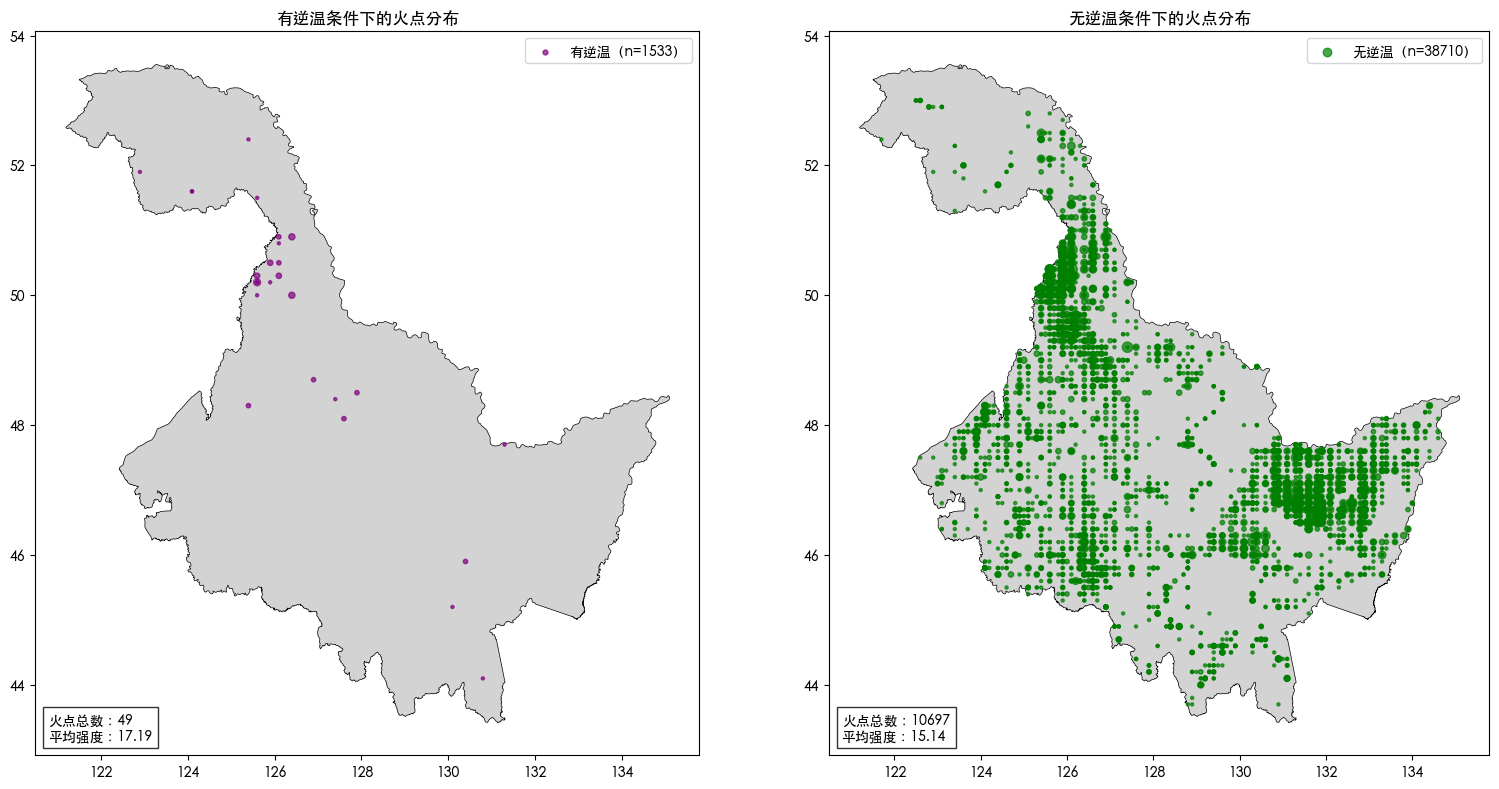


湿度分组统计：
            类别  火点总数     平均火点强度    样本数
0  高湿度（>34.8%）  8125  14.611248  20118
1  低湿度（≤34.8%）  2621  15.819490  20125


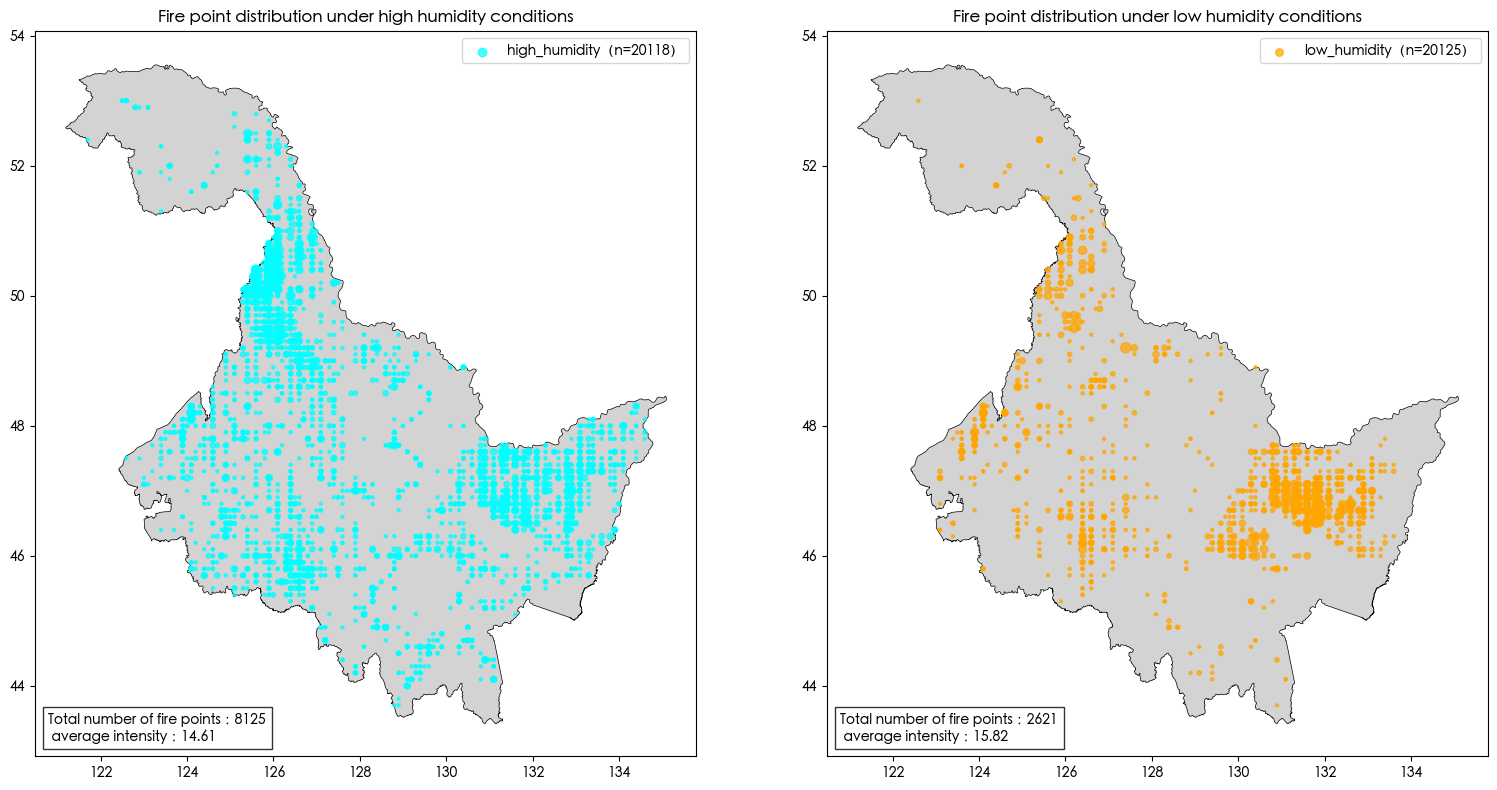

In [40]:
# ---------------------- 1. 数据加载与预处理 ----------------------
# 加载火点数据
fire_data = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")
required_columns = [
    "fire_longitude", "fire_latitude",
    "wind_speed", "2m_relative_humidity", "逆温强度(℃/100m)",
    "秸秆火点数量", "平均火点强度"
]
fire_data_clean = fire_data[required_columns].dropna().copy()

# 创建地理数据框
geometry = [Point(lon, lat) for lon, lat in zip(fire_data_clean["fire_longitude"], fire_data_clean["fire_latitude"])]
gdf = gpd.GeoDataFrame(fire_data_clean, geometry=geometry, crs="EPSG:4326")

# 加载黑龙江省边界并筛选省内火点
china_counties = gpd.read_file("CHN_County.shp")
heilongjiang_counties = china_counties[china_counties["省级"] == "黑龙江省"]
heilongjiang = heilongjiang_counties.dissolve()
gdf_hlj = gpd.sjoin(gdf, heilongjiang, how="inner", predicate="within")


# ---------------------- 2. 逆温现象对火点检测的影响分析 ----------------------
# 分组：有逆温（>0）vs 无逆温（≤0）
gdf_inv_yes = gdf_hlj[gdf_hlj["逆温强度(℃/100m)"] > 0].copy()  # 有逆温
gdf_inv_no = gdf_hlj[gdf_hlj["逆温强度(℃/100m)"] <= 0].copy()   # 无逆温

# 统计数据（辅助解读）
inv_stats = pd.DataFrame({
    "类别": ["有逆温", "无逆温"],
    "火点总数": [gdf_inv_yes["秸秆火点数量"].sum(), gdf_inv_no["秸秆火点数量"].sum()],
    "平均火点强度": [gdf_inv_yes["平均火点强度"].mean(), gdf_inv_no["平均火点强度"].mean()],
    "样本数": [len(gdf_inv_yes), len(gdf_inv_no)]
})
print("逆温分组统计：")
print(inv_stats)

# 绘制逆温对比地图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：有逆温火点分布
heilongjiang.plot(ax=ax1, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_inv_yes.plot(
    ax=ax1,
    color="purple",
    markersize=gdf_inv_yes["秸秆火点数量"] * 5,
    alpha=0.7,
    label=f"有逆温（n={len(gdf_inv_yes)}）"
)
ax1.set_title("有逆温条件下的火点分布", fontsize=12)
ax1.legend()
# 添加统计文本
ax1.text(0.02, 0.02, f"火点总数：{inv_stats.iloc[0,1]}\n平均强度：{inv_stats.iloc[0,2]:.2f}",
         transform=ax1.transAxes, bbox=dict(facecolor="white", alpha=0.8))

# 右图：无逆温火点分布
heilongjiang.plot(ax=ax2, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_inv_no.plot(
    ax=ax2,
    color="green",
    markersize=gdf_inv_no["秸秆火点数量"] * 5,
    alpha=0.7,
    label=f"无逆温（n={len(gdf_inv_no)}）"
)
ax2.set_title("无逆温条件下的火点分布", fontsize=12)
ax2.legend()
ax2.text(0.02, 0.02, f"火点总数：{inv_stats.iloc[1,1]}\n平均强度：{inv_stats.iloc[1,2]:.2f}",
         transform=ax2.transAxes, bbox=dict(facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


# ---------------------- 3. 湿度对火点检测的影响分析 ----------------------
# 分组：高湿度（>中位数）vs 低湿度（≤中位数）
hum_median = gdf_hlj["2m_relative_humidity"].median()
gdf_hum_high = gdf_hlj[gdf_hlj["2m_relative_humidity"] > hum_median].copy()  # 高湿度
gdf_hum_low = gdf_hlj[gdf_hlj["2m_relative_humidity"] <= hum_median].copy()   # 低湿度

# 统计数据
hum_stats = pd.DataFrame({
    "类别": [f"高湿度（>{hum_median:.1f}%）", f"低湿度（≤{hum_median:.1f}%）"],
    "火点总数": [gdf_hum_high["秸秆火点数量"].sum(), gdf_hum_low["秸秆火点数量"].sum()],
    "平均火点强度": [gdf_hum_high["平均火点强度"].mean(), gdf_hum_low["平均火点强度"].mean()],
    "样本数": [len(gdf_hum_high), len(gdf_hum_low)]
})
print("\n湿度分组统计：")
print(hum_stats)

# 绘制湿度对比地图
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：高湿度火点分布
heilongjiang.plot(ax=ax3, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_hum_high.plot(
    ax=ax3,
    color="cyan",
    markersize=gdf_hum_high["秸秆火点数量"] * 5,
    alpha=0.7,
    label=f"high_humidity（n={len(gdf_hum_high)}）"
)
ax3.set_title("Fire point distribution under high humidity conditions", fontsize=12)
ax3.legend()
ax3.text(0.02, 0.02, f"Total number of fire points：{hum_stats.iloc[0,1]}\n average intensity：{hum_stats.iloc[0,2]:.2f}",
         transform=ax3.transAxes, bbox=dict(facecolor="white", alpha=0.8))

# 右图：低湿度火点分布
heilongjiang.plot(ax=ax4, color="lightgray", edgecolor="black", linewidth=0.5)
gdf_hum_low.plot(
    ax=ax4,
    color="orange",
    markersize=gdf_hum_low["秸秆火点数量"] * 5,
    alpha=0.7,
    label=f"low_humidity（n={len(gdf_hum_low)}）"
)
ax4.set_title("Fire point distribution under low humidity conditions", fontsize=12)
ax4.legend()
ax4.text(0.02, 0.02, f"Total number of fire points：{hum_stats.iloc[1,1]}\n average intensity：{hum_stats.iloc[1,2]:.2f}",
         transform=ax4.transAxes, bbox=dict(facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

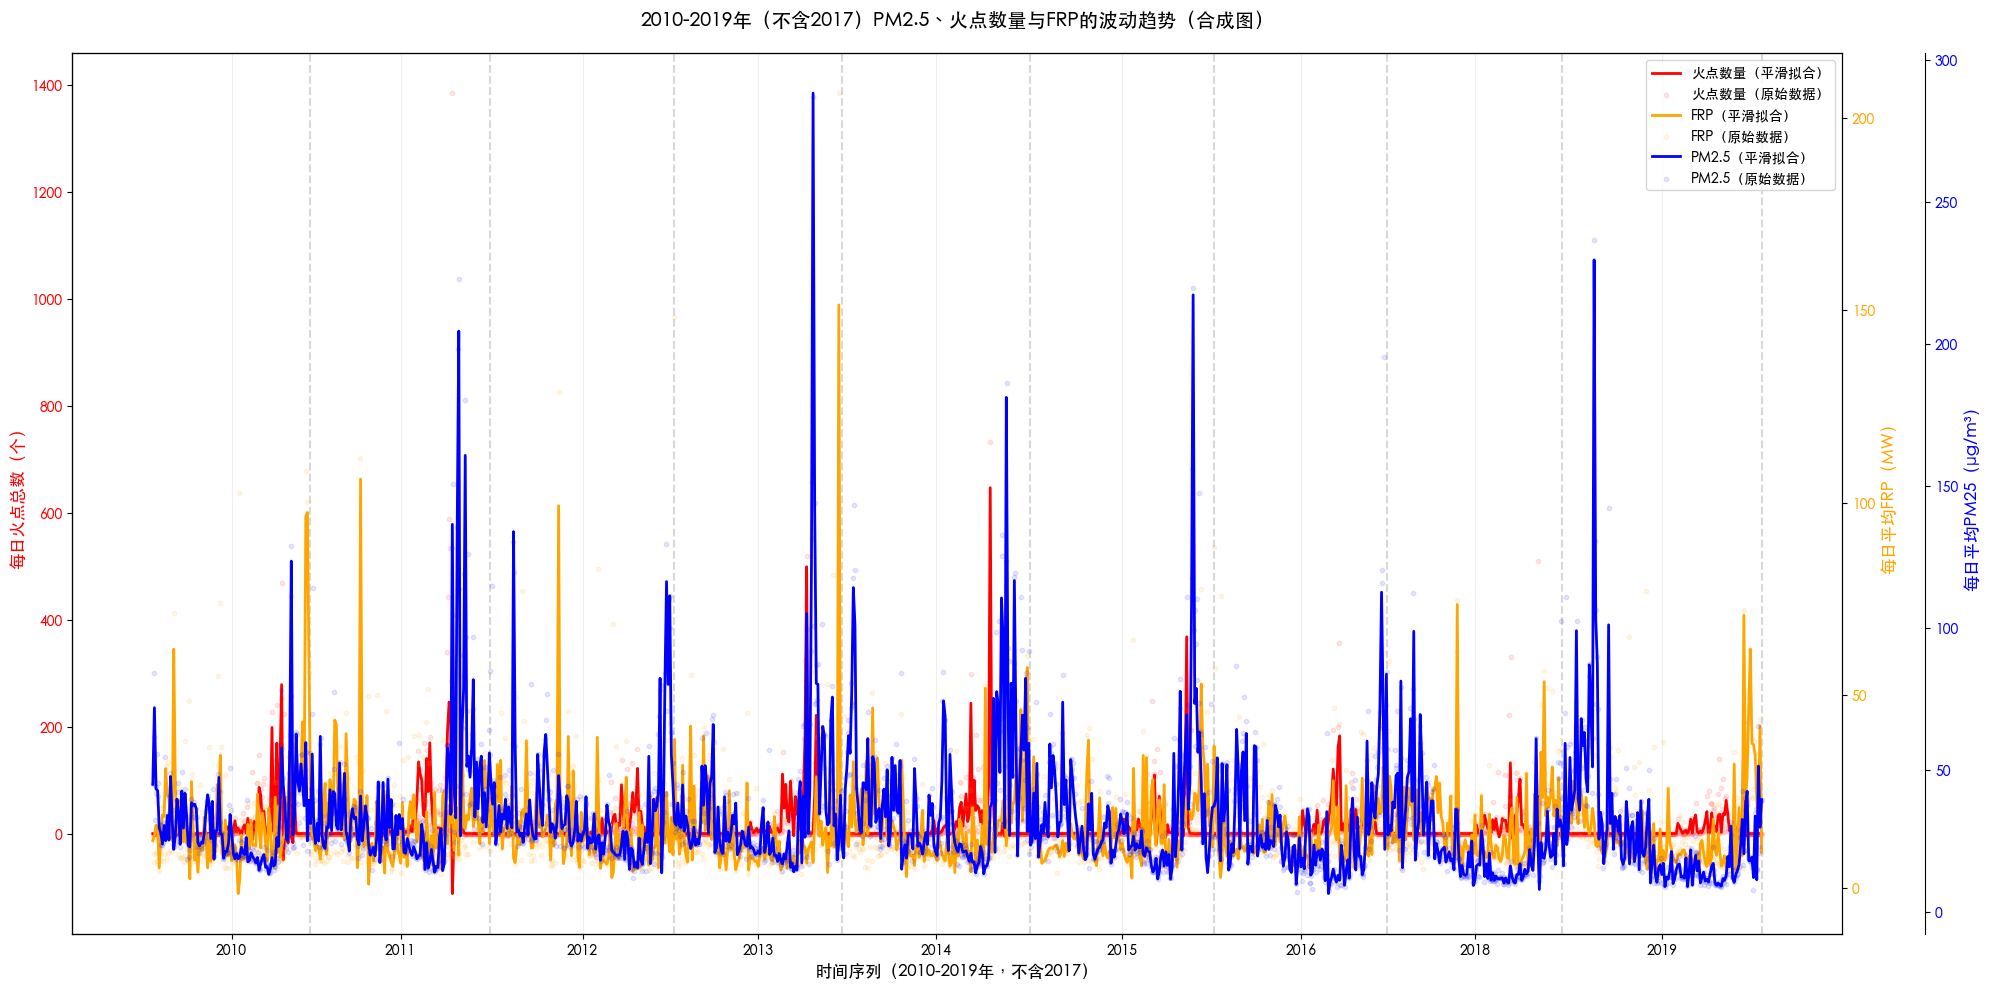

In [42]:
df_final = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")
df_final["date"] = pd.to_datetime(df_final["date"])  

# 按日期聚合，生成每日数据（核心步骤）
df_daily = df_final.groupby("date").agg(
    每日火点总数=("秸秆火点数量", "sum"),         # 每日总火点数量
    每日平均FRP=("平均火点强度", "mean"),       # 每日FRP均值
    每日平均PM25=("pm25_concentration", "mean") # 每日PM25均值
).reset_index()

# ---------------------- 后续可视化代码（基于 df_daily） ----------------------
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Heiti TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据筛选与预处理
df_daily["年份"] = df_daily["date"].dt.year
target_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019]
df_filtered = df_daily[df_daily["年份"].isin(target_years)].copy()

# 填充缺失值（线性插值）
df_filtered[["每日火点总数", "每日平均FRP", "每日平均PM25"]] = df_filtered[
    ["每日火点总数", "每日平均FRP", "每日平均PM25"]
].interpolate(method="linear")

# 按日期排序并生成连续时间索引
df_filtered = df_filtered.sort_values("date").reset_index(drop=True)
df_filtered["时间索引"] = range(len(df_filtered))  # 用连续数字代替日期，避免x轴混乱

# 2. 曲线平滑拟合（三次样条插值）
def smooth_curve(x, y, num_points=1000):
    """对全时间序列进行平滑拟合"""
    x_smooth = np.linspace(x.min(), x.max(), num_points)
    spl = make_interp_spline(x, y, k=3)  # 三次样条确保平滑
    y_smooth = spl(x_smooth)
    return x_smooth, y_smooth

# 拟合三条核心曲线
x_fire, y_fire = smooth_curve(df_filtered["时间索引"], df_filtered["每日火点总数"])
x_frp, y_frp = smooth_curve(df_filtered["时间索引"], df_filtered["每日平均FRP"])
x_pm25, y_pm25 = smooth_curve(df_filtered["时间索引"], df_filtered["每日平均PM25"])

# 3. 绘制合成大图
fig, ax1 = plt.subplots(figsize=(20, 10))  # 宽图适合展示时间序列

# 火点数量曲线（左轴1）
ax1.plot(
    x_fire, y_fire, 
    color="red", linewidth=2, 
    label="火点数量（平滑拟合）"
)
ax1.scatter(
    df_filtered["时间索引"], df_filtered["每日火点总数"], 
    color="red", alpha=0.1, s=10,  # 原始点透明度降低
    label="火点数量（原始数据）"
)
ax1.set_ylabel("每日火点总数（个）", color="red", fontsize=12)
ax1.tick_params(axis="y", labelcolor="red")
ax1.set_xlabel("时间序列（2010-2019年，不含2017）", fontsize=12)

# FRP曲线（左轴2，共享x轴）
ax2 = ax1.twinx()
ax2.plot(
    x_frp, y_frp, 
    color="orange", linewidth=2, 
    label="FRP（平滑拟合）"
)
ax2.scatter(
    df_filtered["时间索引"], df_filtered["每日平均FRP"], 
    color="orange", alpha=0.1, s=10,
    label="FRP（原始数据）"
)
ax2.set_ylabel("每日平均FRP（MW）", color="orange", fontsize=12)
ax2.tick_params(axis="y", labelcolor="orange")

# PM2.5曲线（右轴，共享x轴）
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # 右轴偏移，避免重叠
ax3.plot(
    x_pm25, y_pm25, 
    color="blue", linewidth=2, 
    label="PM2.5（平滑拟合）"
)
ax3.scatter(
    df_filtered["时间索引"], df_filtered["每日平均PM25"], 
    color="blue", alpha=0.1, s=10,
    label="PM2.5（原始数据）"
)
ax3.set_ylabel("每日平均PM25（μg/m³）", color="blue", fontsize=12)
ax3.tick_params(axis="y", labelcolor="blue")

# 添加年份分隔线
year_boundaries = df_filtered.groupby("年份")["时间索引"].max().values
for boundary in year_boundaries:
    ax1.axvline(x=boundary, color="gray", linestyle="--", alpha=0.3)

# 添加年份标签
year_labels = [str(y) for y in target_years]
ax1.set_xticks([df_filtered[df_filtered["年份"] == y]["时间索引"].mean() for y in target_years])
ax1.set_xticklabels(year_labels, fontsize=10)

# 添加标题和图例
plt.title(
    "2010-2019年（不含2017）PM2.5、火点数量与FRP的波动趋势（合成图）",
    fontsize=14, pad=20
)
# 合并三个轴的图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="upper right",
    fontsize=10
)

# 添加网格
ax1.grid(axis="x", alpha=0.2)

# 调整布局并保存
plt.tight_layout()
plt.savefig("PM25_火点_FRP合成波动图.png", dpi=300, bbox_inches="tight")
plt.show()

原始数据中'秸秆火点数量'的基本信息：
数据类型：int64
缺失值数量：0
最小值：0，最大值：15

清洗后的数据验证：
总数据量：124508行
火点数量>0的数据量：17681行（非零火点）
火点数量统计：
count    124508.000000
mean          0.234523
std           0.746526
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          15.000000
Name: 秸秆火点数量, dtype: float64

识别到的秸秆焚烧事件数量：445
焚烧事件示例：
    焚烧事件ID  焚烧总火点数
0       1       8
1       2       5
2       3       5
3       4       3
4       5      10
匹配到的事件对数量：16335

年度汇总（含火点数据）：
     年份  秸秆焚烧事件数  总火点数  PM2.5峰值事件数  平均PM2.5峰值浓度  匹配事件对数
0  2010       58  4446         177   113.115828    2165
1  2011       87  6887         366   124.429293    7091
2  2012       37  1893         131   112.854607     364
3  2013       67  3317         323   133.912119    2590
4  2014       41  2352         580   146.839737    1646
5  2015       45  2708         720   134.438654    1981
6  2016       44  2641         329   102.919676     492
7  2018       34  2652         171   103.120457       0
8  2019   

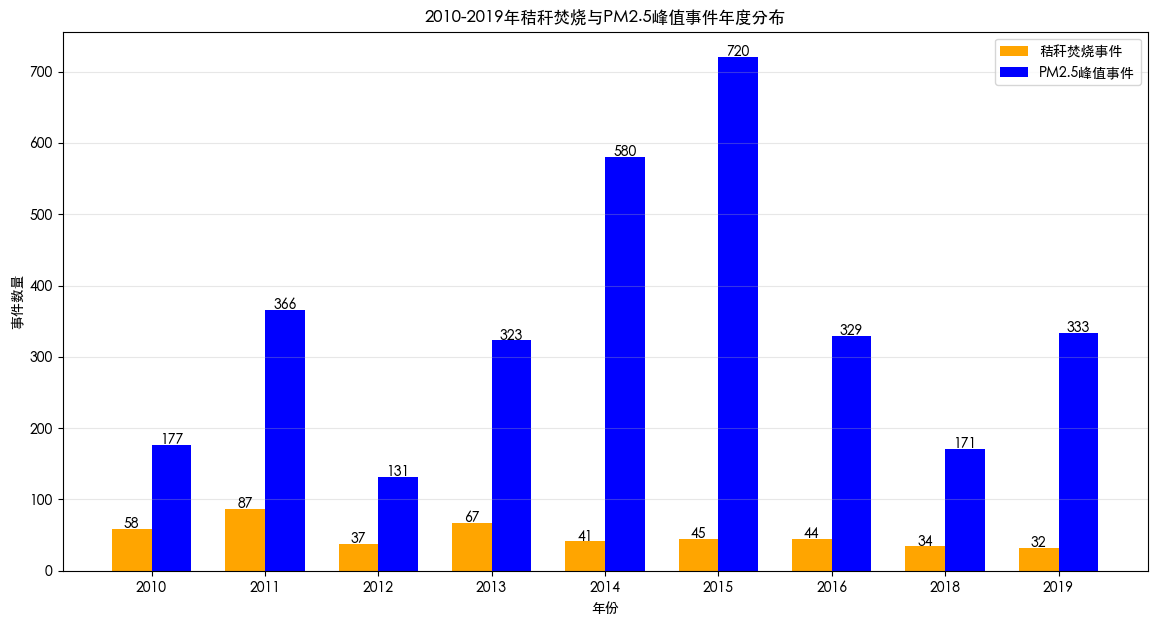

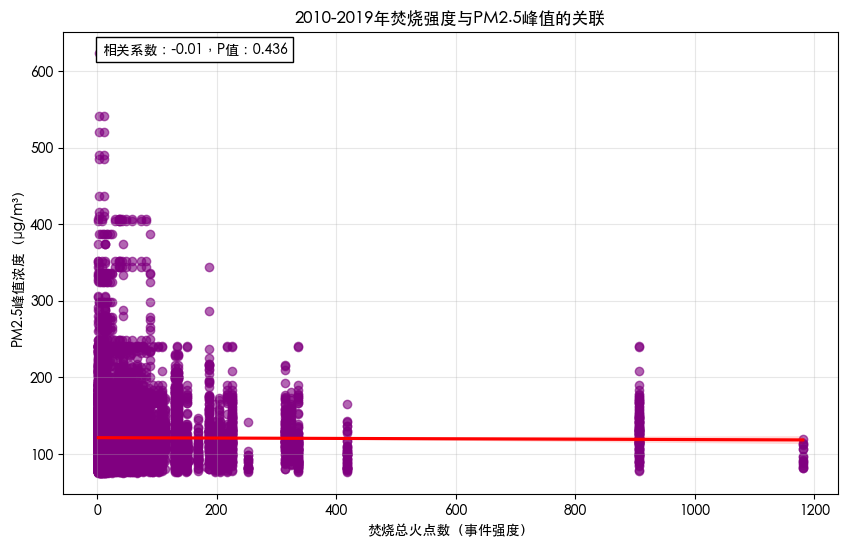

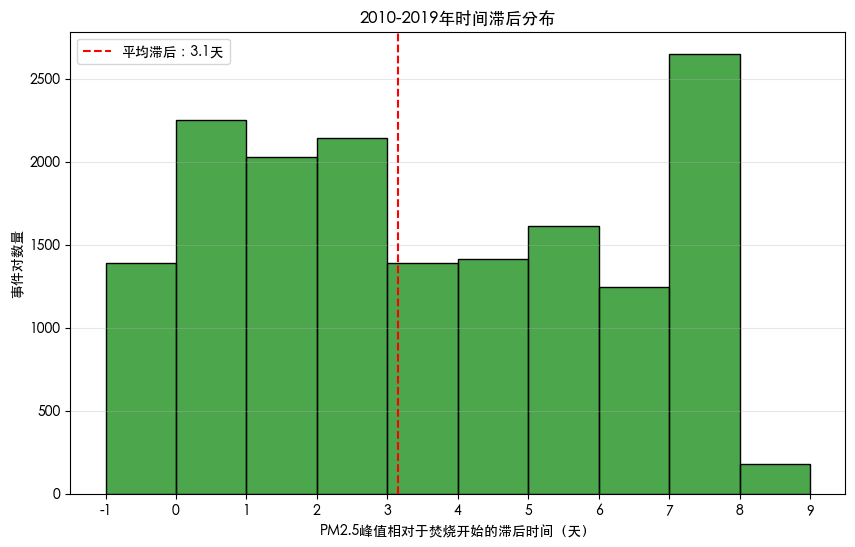

In [63]:
# --------------------------
# 第一步：数据加载与清洗
# --------------------------
# 1. 加载数据
df = pd.read_csv("火点_气象_PM25_三者匹配结果_总-V1.csv")

# 2. 关键：检查“秸秆火点数量”字段状态
print("原始数据中'秸秆火点数量'的基本信息：")
print(f"数据类型：{df['秸秆火点数量'].dtype}")
print(f"缺失值数量：{df['秸秆火点数量'].isna().sum()}")
print(f"最小值：{df['秸秆火点数量'].min(skipna=True)}，最大值：{df['秸秆火点数量'].max(skipna=True)}")

# 3. 处理可能的问题：转换为数值型+填充缺失值（缺失视为0火点）
df["秸秆火点数量"] = pd.to_numeric(df["秸秆火点数量"], errors="coerce")  # 转换为数值，无效值设为NaN
df["秸秆火点数量"] = df["秸秆火点数量"].fillna(0)  # 缺失值视为0火点

# 4. 转换日期格式
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df[df["date"].notna()].copy()  # 过滤无效日期

# 5. 修正清洗条件：保留所有非负火点（包括0），仅过滤异常值
df_clean = df[
    (df["秸秆火点数量"] >= 0) &  # 允许0（无焚烧），仅排除负数
    (df["pm25_concentration"] > 0) &
    (df["wind_speed"] >= 0) &
    (df["2m_relative_humidity"].between(0, 100)) &
    (df["匹配距离(°)"] <= 0.2) &
    (df["PM2.5匹配距离(°)"] <= 0.3)
].copy()

# 6. 检查清洗后的数据是否保留火点
print("\n清洗后的数据验证：")
print(f"总数据量：{df_clean.shape[0]}行")
print(f"火点数量>0的数据量：{df_clean[df_clean['秸秆火点数量'] > 0].shape[0]}行（非零火点）")
print(f"火点数量统计：\n{df_clean['秸秆火点数量'].describe()}")  # 确保有正数值


# --------------------------
# 第二步：事件识别函数
# --------------------------
def identify_straw_burn_events(df, fire_threshold=1, consecutive_days=2):
    """降低阈值：单天火点>=1个即视为有效焚烧日（根据数据实际情况调整）"""
    df_sorted = df.sort_values("date").reset_index(drop=True)
    df_sorted["有效焚烧日"] = (df_sorted["秸秆火点数量"] >= fire_threshold).astype(int)
    
    df_sorted["事件标识"] = 0
    event_id = 1
    consecutive_count = 0
    
    for idx in df_sorted.index:
        if df_sorted.loc[idx, "有效焚烧日"] == 1:
            consecutive_count += 1
            if consecutive_count >= consecutive_days:
                start_idx = idx - (consecutive_count - 1)
                df_sorted.loc[start_idx:idx, "事件标识"] = event_id
        else:
            if consecutive_count >= consecutive_days:
                event_id += 1
            consecutive_count = 0
    
    burn_events = df_sorted[df_sorted["事件标识"] > 0].groupby("事件标识").agg(
        焚烧事件ID=("事件标识", "first"),
        焚烧开始日期=("date", "min"),
        焚烧结束日期=("date", "max"),
        焚烧总火点数=("秸秆火点数量", "sum")
    ).reset_index(drop=True)
    return df_sorted, burn_events


# 其他函数保持不变
def identify_pm25_peak_events(df, pm25_threshold=75, consecutive_days=2):
    df_sorted = df.sort_values("date").reset_index(drop=True)
    df_sorted["PM25污染日"] = (df_sorted["pm25_concentration"] >= pm25_threshold).astype(int)
    
    df_sorted["PM25事件标识"] = 0
    pm25_event_id = 1
    consecutive_pollute = 0
    
    for idx in df_sorted.index:
        if df_sorted.loc[idx, "PM25污染日"] == 1:
            consecutive_pollute += 1
            if consecutive_pollute >= consecutive_days:
                start_idx = idx - (consecutive_pollute - 1)
                df_sorted.loc[start_idx:idx, "PM25事件标识"] = pm25_event_id
        else:
            if consecutive_pollute >= consecutive_days:
                pm25_event_id += 1
            consecutive_pollute = 0
    
    pm25_peak_events = df_sorted[df_sorted["PM25事件标识"] > 0].groupby("PM25事件标识").agg(
        PM25事件ID=("PM25事件标识", "first"),
        PM25峰值日期=("pm25_concentration", lambda x: df_sorted.loc[x.idxmax(), "date"]),
        PM25峰值浓度=("pm25_concentration", "max")
    ).reset_index(drop=True)
    return df_sorted, pm25_peak_events


def match_burn_pm25_events(straw_burn_events, pm25_peak_events, time_window=7):
    matched_pairs = []
    for _, burn_event in straw_burn_events.iterrows():
        burn_start = burn_event["焚烧开始日期"]
        burn_end = burn_event["焚烧结束日期"]
        window_start = burn_start - pd.Timedelta(days=1)
        window_end = burn_end + pd.Timedelta(days=time_window)
        
        matched_pm25 = pm25_peak_events[
            (pm25_peak_events["PM25峰值日期"] >= window_start) &
            (pm25_peak_events["PM25峰值日期"] <= window_end)
        ]
        
        for _, pm25_event in matched_pm25.iterrows():
            lag_days = (pm25_event["PM25峰值日期"] - burn_start).days
            matched_pairs.append({
                "焚烧事件ID": burn_event["焚烧事件ID"],
                "PM25事件ID": pm25_event["PM25事件ID"],
                "焚烧开始日期": burn_start,
                "PM25峰值日期": pm25_event["PM25峰值日期"],
                "时间滞后（天）": lag_days,
                "焚烧总火点数": burn_event["焚烧总火点数"],
                "PM25峰值浓度": pm25_event["PM25峰值浓度"]
            })
    return pd.DataFrame(matched_pairs)


# --------------------------
# 第三步：整体分析
# --------------------------
plt.rcParams["font.family"] = ["Heiti TC"]
plt.rcParams['axes.unicode_minus'] = False

# 1. 识别事件（降低火点阈值，确保能识别到事件）
df_all_events, straw_burn_all = identify_straw_burn_events(
    df_clean, fire_threshold=1, consecutive_days=2  # 单天1个火点+连续2天即视为事件
)
print(f"\n识别到的秸秆焚烧事件数量：{len(straw_burn_all)}")
if len(straw_burn_all) > 0:
    print("焚烧事件示例：\n", straw_burn_all[["焚烧事件ID", "焚烧总火点数"]].head())

df_all_events, pm25_peak_all = identify_pm25_peak_events(
    df_all_events, pm25_threshold=75, consecutive_days=2
)

# 2. 匹配事件对
matched_all = match_burn_pm25_events(
    straw_burn_all, pm25_peak_all, time_window=7
)
print(f"匹配到的事件对数量：{len(matched_all)}")


# --------------------------
# 第四步：可视化与分析
# --------------------------
# 1. 年度汇总
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019]
yearly_summary = pd.DataFrame()

for year in years:
    burn_year = straw_burn_all[straw_burn_all["焚烧开始日期"].dt.year == year]
    pm25_year = pm25_peak_all[pm25_peak_all["PM25峰值日期"].dt.year == year]
    matched_year = matched_all[matched_all["焚烧开始日期"].dt.year == year]
    
    yearly_summary = pd.concat([yearly_summary, pd.DataFrame({
        "年份": [year],
        "秸秆焚烧事件数": [len(burn_year)],
        "总火点数": [burn_year["焚烧总火点数"].sum() if not burn_year.empty else 0],
        "PM2.5峰值事件数": [len(pm25_year)],
        "平均PM2.5峰值浓度": [pm25_year["PM25峰值浓度"].mean() if not pm25_year.empty else 0],
        "匹配事件对数": [len(matched_year)]
    })], ignore_index=True)

print("\n年度汇总（含火点数据）：")
print(yearly_summary)


# 2. 可视化
if len(straw_burn_all) > 0:
    # 年度事件数量对比
    plt.figure(figsize=(14, 7))
    x = np.arange(len(years))
    width = 0.35
    plt.bar(x - width/2, yearly_summary["秸秆焚烧事件数"], width, label="秸秆焚烧事件", color="orange")
    plt.bar(x + width/2, yearly_summary["PM2.5峰值事件数"], width, label="PM2.5峰值事件", color="blue")
    for i, (b, p) in enumerate(zip(yearly_summary["秸秆焚烧事件数"], yearly_summary["PM2.5峰值事件数"])):
        plt.text(i - width/2, b + 0.5, f"{b}", ha="center")
        plt.text(i + width/2, p + 0.5, f"{p}", ha="center")
    plt.xlabel("年份")
    plt.ylabel("事件数量")
    plt.title("2010-2019年秸秆焚烧与PM2.5峰值事件年度分布")
    plt.xticks(x, years)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# 焚烧强度与PM2.5相关性
if len(matched_all) > 0 and "焚烧总火点数" in matched_all.columns:
    valid_matched = matched_all[(matched_all["焚烧总火点数"] > 0) & (matched_all["PM25峰值浓度"] > 0)]
    if len(valid_matched) > 0:
        corr, p = stats.pearsonr(valid_matched["焚烧总火点数"], valid_matched["PM25峰值浓度"])
        plt.figure(figsize=(10, 6))
        sns.regplot(x="焚烧总火点数", y="PM25峰值浓度", data=valid_matched,
                   scatter_kws={"alpha": 0.6, "color": "purple"}, line_kws={"color": "red"})
        plt.text(0.05, 0.95, f"相关系数：{corr:.2f}，P值：{p:.3f}",
                 transform=plt.gca().transAxes, bbox=dict(facecolor="white"))
        plt.xlabel("焚烧总火点数（事件强度）")
        plt.ylabel("PM2.5峰值浓度（μg/m³）")
        plt.title("2010-2019年焚烧强度与PM2.5峰值的关联")
        plt.grid(alpha=0.3)
        plt.show()


# 时间滞后分布
if len(matched_all) > 0 and "时间滞后（天）" in matched_all.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(matched_all["时间滞后（天）"], bins=range(-1, 10),
                color="green", alpha=0.7, edgecolor="black")
    mean_lag = matched_all["时间滞后（天）"].mean()
    plt.axvline(x=mean_lag, color="red", linestyle="--", label=f"平均滞后：{mean_lag:.1f}天")
    plt.xlabel("PM2.5峰值相对于焚烧开始的滞后时间（天）")
    plt.ylabel("事件对数量")
    plt.title("2010-2019年时间滞后分布")
    plt.xticks(range(-1, 10))
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()

2015年数据量：21933行
2015年火点数量统计：
count    21933.000000
mean         0.125655
std          0.534924
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         12.000000
Name: 秸秆火点数量, dtype: float64

2015年典型焚烧事件：ID=34
焚烧时段：2015-10-25至2015-10-25
总火点数：24，对应PM2.5峰值：94.83581906710948μg/m³


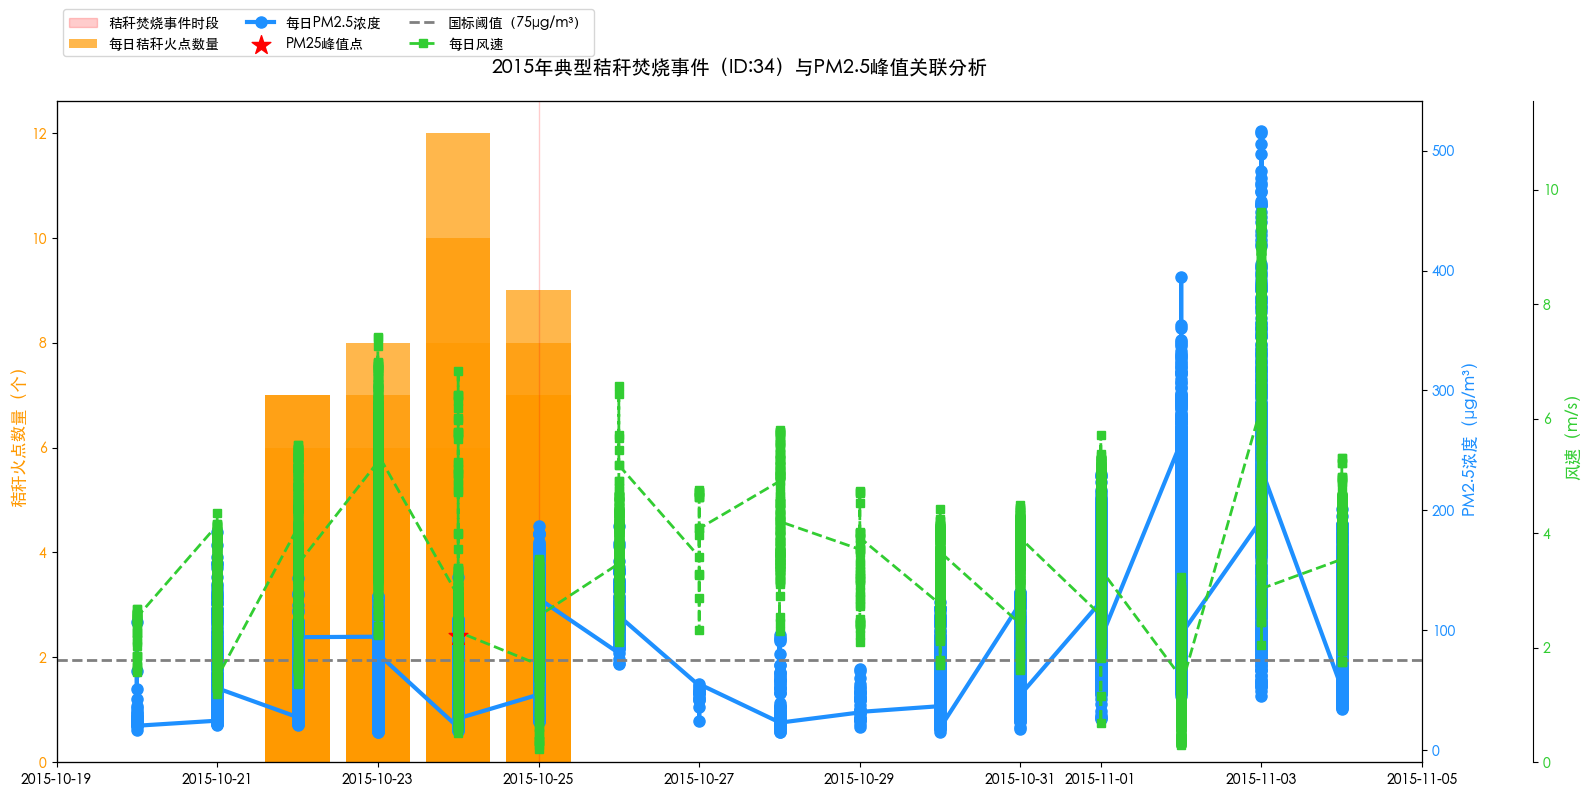


典型事件关键指标：
焚烧期间平均火点数：0.4个/天
PM25峰值浓度：18.788076224400445μg/m³（超标-74.9%）
峰值日风速：2.9010315m/s（低风速易累积污染）
焚烧开始至PM25峰值滞后时间：-1天


In [62]:
# --------------------------
# 第一步：数据准备（基于已清洗的df_clean）
# --------------------------
# 1. 筛选2015年数据
df_2015 = df_clean[df_clean["date"].dt.year == 2015].copy()
print(f"2015年数据量：{df_2015.shape[0]}行")
print(f"2015年火点数量统计：\n{df_2015['秸秆火点数量'].describe()}")

# 2. 识别2015年的秸秆焚烧事件和PM2.5峰值事件
df_2015_events, straw_burn_2015 = identify_straw_burn_events(
    df_2015, fire_threshold=3, consecutive_days=2  # 适配2015年数据的阈值
)
df_2015_events, pm25_peak_2015 = identify_pm25_peak_events(
    df_2015_events, pm25_threshold=75, consecutive_days=2
)

# 3. 匹配事件对（获取2015年关联最强的典型事件）
matched_2015 = match_burn_pm25_events(
    straw_burn_2015, pm25_peak_2015, time_window=7
)
# 按“焚烧总火点数×PM2.5峰值浓度”排序，选取关联最强的事件
matched_2015["关联强度"] = matched_2015["焚烧总火点数"] * matched_2015["PM25峰值浓度"]
typical_burn_id = matched_2015.sort_values("关联强度", ascending=False)["焚烧事件ID"].iloc[0]

# 提取典型事件详情
typical_burn = straw_burn_2015[straw_burn_2015["焚烧事件ID"] == typical_burn_id].iloc[0]
typical_pm25 = matched_2015[matched_2015["焚烧事件ID"] == typical_burn_id].iloc[0]

print(f"\n2015年典型焚烧事件：ID={typical_burn_id}")
print(f"焚烧时段：{typical_burn['焚烧开始日期'].date()}至{typical_burn['焚烧结束日期'].date()}")
print(f"总火点数：{typical_burn['焚烧总火点数']}，对应PM2.5峰值：{typical_pm25['PM25峰值浓度']}μg/m³")


# --------------------------
# 第二步：绘制典型年峰值分析图
# --------------------------
# 1. 提取事件前后15天的时间序列数据（含气象）
time_range = pd.date_range(
    start=typical_burn["焚烧开始日期"] - pd.Timedelta(days=5),  # 事件前5天
    end=typical_burn["焚烧结束日期"] + pd.Timedelta(days=10),  # 事件后10天
    freq="D"
)
plot_data = df_2015_events[df_2015_events["date"].isin(time_range)].sort_values("date").copy()

# 2. 创建画布和坐标轴
fig, ax1 = plt.subplots(figsize=(16, 8))

# 3. 左轴1：秸秆火点数量（柱状图）
ax1.bar(
    plot_data["date"], plot_data["秸秆火点数量"],
    color="#FF9900", alpha=0.7, label="每日秸秆火点数量"
)
# 标记焚烧事件时段（红色阴影）
ax1.axvspan(
    typical_burn["焚烧开始日期"], typical_burn["焚烧结束日期"],
    alpha=0.2, color="red", label="秸秆焚烧事件时段"
)
ax1.set_ylabel("秸秆火点数量（个）", color="#FF9900", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#FF9900")
ax1.set_xlim(plot_data["date"].min() - pd.Timedelta(days=1), 
             plot_data["date"].max() + pd.Timedelta(days=1))  # 扩展X轴范围

# 4. 右轴1：PM2.5浓度（折线图）
ax2 = ax1.twinx()
ax2.plot(
    plot_data["date"], plot_data["pm25_concentration"],
    color="#1E90FF", linewidth=3, marker="o", markersize=8, label="每日PM2.5浓度"
)
# 标记PM2.5峰值点（红色五角星）
ax2.scatter(
    typical_pm25["PM25峰值日期"], typical_pm25["PM25峰值浓度"],
    color="red", s=200, marker="*", zorder=5, label="PM25峰值点"
)
# 绘制PM2.5国标阈值线（75μg/m³）
ax2.axhline(y=75, color="gray", linestyle="--", linewidth=2, label="国标阈值（75μg/m³）")
ax2.set_ylabel("PM2.5浓度（μg/m³）", color="#1E90FF", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#1E90FF")

# 5. 右轴2：风速（辅助分析扩散条件，虚线）
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 80))  # 偏移右轴避免重叠
ax3.plot(
    plot_data["date"], plot_data["wind_speed"],
    color="#32CD32", linewidth=2, linestyle="--", marker="s", label="每日风速"
)
ax3.set_ylabel("风速（m/s）", color="#32CD32", fontsize=12)
ax3.tick_params(axis="y", labelcolor="#32CD32")
ax3.set_ylim(0, plot_data["wind_speed"].max() * 1.2)  # 调整风速轴范围

# 6. 标题和图例
plt.title(
    f"2015年典型秸秆焚烧事件（ID:{typical_burn_id}）与PM2.5峰值关联分析",
    fontsize=14, pad=20
)
# 合并三个轴的图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="upper left",
    fontsize=10,
    bbox_to_anchor=(0, 1.15),  # 图例放在图上方
    ncol=3
)

# 7. 美化格式
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------
# 第三步：典型事件的关键指标统计
# --------------------------
# 计算事件期间及峰值前后的核心指标
event_period = plot_data[
    (plot_data["date"] >= typical_burn["焚烧开始日期"]) &
    (plot_data["date"] <= typical_burn["焚烧结束日期"])
]
peak_day = plot_data[plot_data["date"] == typical_pm25["PM25峰值日期"]]

print("\n典型事件关键指标：")
print(f"焚烧期间平均火点数：{event_period['秸秆火点数量'].mean():.1f}个/天")
print(f"PM25峰值浓度：{peak_day['pm25_concentration'].values[0]}μg/m³（超标{peak_day['pm25_concentration'].values[0]/75-1:.1%}）")
print(f"峰值日风速：{peak_day['wind_speed'].values[0]}m/s（低风速易累积污染）")
print(f"焚烧开始至PM25峰值滞后时间：{typical_pm25['时间滞后（天）']}天")